# PVE Signal Sensitivity Analysis

Does increasing the proportion of variance explained (PVE) in the data
make our agents' responses more distinguishable from the null?

For each PVE level (0.0, 0.5, 1.0) and each dataset, we pool the PVE
responses as the alt group and the existing null responses as the null
group, then run an unblocked difference-in-means permutation test.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")

BASE_DIR = Path("..").resolve()
sys.path.insert(0, str(BASE_DIR / "scripts"))

from calibration_sim import unblocked_perm_pvalue

In [2]:
# Load data
pve_path = BASE_DIR / "aggregated_results" / "aggregated_pve_results.csv"
null_path = BASE_DIR / "aggregated_results" / "aggregated_results.csv"

if not pve_path.exists():
    raise FileNotFoundError(
        f"Missing {pve_path.name}. Run scripts/aggregate_pve_conclusions.py first."
    )
if not null_path.exists():
    raise FileNotFoundError(
        f"Missing {null_path.name}. Run scripts/aggregate_conclusions.py first."
    )

df_pve = pd.read_csv(pve_path, keep_default_na=False)
df_null = pd.read_csv(null_path, keep_default_na=False)

# Keep only null-distribution rows from the main results
df_null = df_null[df_null["distribution"] == "null"].copy()

pve_levels = sorted(df_pve["pve_level"].unique(), key=float)
datasets = sorted(df_pve["dataset"].unique())

print(f"PVE levels: {pve_levels}")
print(f"Datasets: {datasets}")
print(f"PVE rows: {len(df_pve)}, null rows: {len(df_null)}")

PVE levels: [0.0, 0.005, 0.01, 0.025, 0.05, 0.2, 0.4, 0.5, 0.6, 1.0]
Datasets: ['affairs', 'amtl']
PVE rows: 183, null rows: 500


In [3]:
# One-sided permutation tests: PVE responses (alt) vs null responses
B = 2000
SEED = 42
rng = np.random.default_rng(SEED)

results = []
for ds in datasets:
    null_scores = df_null.loc[df_null["dataset"] == ds, "response"].values.astype(float)
    if len(null_scores) == 0:
        print(f"  {ds}: no null responses, skipping")
        continue

    for level in pve_levels:
        alt_scores = df_pve.loc[
            (df_pve["dataset"] == ds) & (df_pve["pve_level"] == level),
            "response",
        ].values.astype(float)

        if len(alt_scores) == 0:
            continue

        y = np.concatenate([alt_scores, null_scores])
        n_alt = len(alt_scores)

        p = unblocked_perm_pvalue(y, n_alt, B, agg=np.mean, rng=rng)

        results.append({
            "dataset": ds,
            "pve_level": float(level),
            "n_alt": n_alt,
            "n_null": len(null_scores),
            "alt_mean": alt_scores.mean(),
            "null_mean": null_scores.mean(),
            "p_value": p,
        })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False, float_format="%.4f"))

dataset  pve_level  n_alt  n_null  alt_mean  null_mean  p_value
affairs     0.0000      1     100   30.0000    30.4500   0.4128
affairs     0.5000      1     100    5.0000    30.4500   1.0000
affairs     1.0000      1     100    2.0000    30.4500   1.0000
   amtl     0.0000     25     100   18.0000    26.5000   0.9950
   amtl     0.0050     25     100   38.1200    26.5000   0.0010
   amtl     0.0100     25     100   65.7200    26.5000   0.0005
   amtl     0.0250     25     100   78.2800    26.5000   0.0005
   amtl     0.0500      5     100   86.2000    26.5000   0.0005
   amtl     0.2000     25     100   90.7600    26.5000   0.0005
   amtl     0.4000     25     100   92.4800    26.5000   0.0005
   amtl     0.6000     25     100   93.5200    26.5000   0.0005


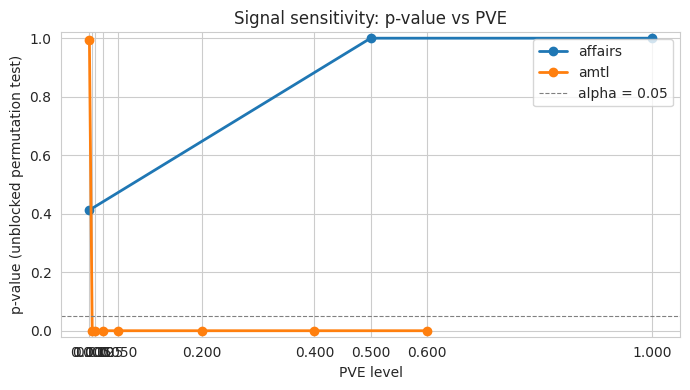

In [4]:
# Plot: p-value vs PVE level, per dataset
fig, ax = plt.subplots(figsize=(7, 4))

palette = sns.color_palette("tab10", n_colors=len(datasets))
for i, ds in enumerate(datasets):
    sub = results_df[results_df["dataset"] == ds]
    ax.plot(
        sub["pve_level"], sub["p_value"],
        marker="o", label=ds, color=palette[i], linewidth=2,
    )

ax.axhline(0.05, color="gray", linestyle="--", linewidth=0.8, label="alpha = 0.05")
ax.set_xlabel("PVE level")
ax.set_ylabel("p-value (unblocked permutation test)")
ax.set_title("Signal sensitivity: p-value vs PVE")
ax.set_xticks(sorted(results_df["pve_level"].unique()))
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()